# Trabajo Practico Grupal
## Laboratorio de Metodos Cuantitativos · FCE UBA · 1C 2026

---

### Sobre la empresa analizada

**General Cereals S.A.** es una empresa argentina de capitales nacionales fundada en 1994, dedicada a la elaboracion de cereales para el desayuno bajo su marca principal **NUTRI FOODS**. Su portfolio incluye cereales azucarados (copos, bolitas, anillos, almohaditas) y productos naturales (avena, granola, salvado), tanto para consumo hogar como insumos industriales. En 2014 fue adquirida por el **Grupo Georgalos** y actualmente exporta a mas de 10 paises.

---

### Pregunta de investigacion

> **¿Los productos de General Cereals que recibieron octogonos de advertencia por la Ley 27.642 de etiquetado frontal vendieron menos unidades que los que no los recibieron, teniendo en cuenta que la inflacion ya de por si redujo el consumo general?**

---

**Indice:** 3.1 Carga y exploracion · 3.2 Pregunta de investigacion · 3.3 Transformaciones · 3.4 Analisis grafico · 3.5 Conceptos de la materia


---
# 3.1 — Carga y exploracion inicial

Antes de responder cualquier pregunta con datos, hay que conocer el dataset a fondo. En esta seccion cargamos el archivo, inspeccionamos su estructura, verificamos su calidad y entendemos que productos y periodos cubre. Cada hallazgo aqui justifica las decisiones de las secciones siguientes.


In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sympy as sp
import warnings
warnings.filterwarnings('ignore')
!pip install scipy

print('Librerias importadas correctamente.')


Librerias importadas correctamente.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\lcarb\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


## Carga del dataset con `pd.read_csv()`

El dataset fue preparado con separador punto y coma (`;`) para evitar conflictos con las comas internas en nombres de productos y localidades. `encoding='utf-8-sig'` permite leer correctamente tildes y enyes.


In [68]:
df = pd.read_csv('Dataset_Limpio.csv', sep=';', encoding='utf-8-sig')

print(f'Filas (transacciones): {df.shape[0]:,}')
print(f'Columnas (atributos):  {df.shape[1]}')


Filas (transacciones): 54,769
Columnas (atributos):  53


## Primeras y ultimas filas: `.head()` y `.tail()`

`.head()` muestra las primeras 5 filas y `.tail()` las ultimas 5. Verificamos que la carga fue correcta en ambos extremos y que los valores tienen sentido.

Mostramos solo las columnas relevantes para nuestra pregunta:

| Columna | Rol en el analisis |
|---|---|
| `FECHA` | Separar transacciones antes y despues de la ley (jul-2022) |
| `FORMULARIO` | Diferenciar ventas reales (FCD) de devoluciones (NCD) |
| `DETALLE` | Nombre especifico del producto |
| `PRECIO` | Medir el contexto inflacionario |
| `CANTIDAD` | Variable principal: lo que queremos comparar |
| `SUBRUBRO_BI` | Base para clasificar si el producto lleva octogono |
| `MARCA_BI` | Marca del producto |
| `AÑO` | Comparaciones anuales |


In [69]:
COLS = ['FECHA','FORMULARIO','DETALLE','PRECIO','CANTIDAD','SUBRUBRO_BI','MARCA_BI','AÑO']

print('=== PRIMERAS 5 FILAS ===')
display(df[COLS].head())

print('\n=== ULTIMAS 5 FILAS ===')
display(df[COLS].tail())


=== PRIMERAS 5 FILAS ===


,FECHA,FORMULARIO,DETALLE,PRECIO,CANTIDAD,SUBRUBRO_BI,MARCA_BI,AÑO
0,18/01/2022,FCD,RICE GRANDE M 1 X 15 KG,2459.70,6000.0,CRISPIES,INDUSTRIALES,2022
1,20/01/2022,FCD,COPO AZUCARADO LACTEAS x13Kg,2120.24,7020.0,COPOS,INDUSTRIALES,2022
2,20/01/2022,FCD,COPOS DE MAIZ CUQUETS 8x400g,609.84,1440.0,COPOS,DIA,2022
3,20/01/2022,FCD,BOLITAS DE CHOCOLATE DIA 10x200g,565.95,5040.0,BOLITAS,DIA,2022
4,20/01/2022,FCD,ANILLOS FRUTALES DIA 10x200g,528.99,5760.0,ANILLOS,DIA,2022



=== ULTIMAS 5 FILAS ===


,FECHA,FORMULARIO,DETALLE,PRECIO,CANTIDAD,SUBRUBRO_BI,MARCA_BI,AÑO
54764,23/12/2024,NCD,BOLITAS NF NUTRI CHOK 20x200g,17195.76,-50.0,BOLITAS,NUTRI FOODS,2024
54765,23/12/2024,NCD,BOLITA DE CHOCOLATE NF 4 X2500G,30728.70,-50.0,BOLITAS,NUTRI FOODS,2024
54766,23/12/2024,NCD,GRANOLA 5 SEMILLAS NF 7x1kg,28838.05,-20.0,GRANOLA,NUTRI FOODS,2024
54767,23/12/2024,NCD,BOLITAS NF NUTRI CHOK 20x200g,17195.76,-100.0,BOLITAS,NUTRI FOODS,2024
54768,23/12/2024,NCD,BOLITA DE CHOCOLATE NF 4 X2500G,30728.70,-50.0,BOLITAS,NUTRI FOODS,2024


## Estructura: `.info()`

`.info()` muestra el nombre de cada columna, cuantos valores no nulos tiene y su tipo de dato. Si una columna numerica aparece como `object` (texto), hay que convertirla antes de operar con ella.


In [70]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 54769 entries, 0 to 54768
Data columns (total 53 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   #                54769 non-null  int64  
 1   FECHA            54769 non-null  str    
 2   HORA             0 non-null      float64
 3   EMPRESA          0 non-null      float64
 4   NOMB_EMP         0 non-null      float64
 5   FORMULARIO       54769 non-null  str    
 6   NNUMERO          54769 non-null  int64  
 7   CONDICION        0 non-null      float64
 8   ALTER            0 non-null      float64
 9   CODIGO           54769 non-null  int64  
 10  NOMBRE           54769 non-null  str    
 11  COD_ALFA         54769 non-null  int64  
 12  DETALLE          54769 non-null  str    
 13  PRECIO           54769 non-null  float64
 14  CANTIDAD         54767 non-null  float64
 15  VENDEDOR         0 non-null      float64
 16  NOMB_VEND        54769 non-null  str    
 17  RUBRO            54769 

## Conversion de FECHA y creacion de AÑO_MES

`pd.to_datetime()` convierte el texto `'18/01/2022'` a un objeto fecha real, lo que permite hacer comparaciones como 'antes o despues de julio 2022'. `.dt.to_period('M')` extrae el mes para agrupar transacciones por mes en los graficos.


In [71]:
df['FECHA'] = pd.to_datetime(df['FECHA'], format='%d/%m/%Y', errors='coerce')
df['AÑO_MES'] = df['FECHA'].dt.to_period('M')

print(f'Tipo de FECHA: {df["FECHA"].dtype}')
print(f'Ejemplo AÑO_MES: {df["AÑO_MES"].iloc[0]}')


Tipo de FECHA: datetime64[us]
Ejemplo AÑO_MES: 2022-01


## Estadisticas descriptivas: `.describe()`

`.describe()` calcula automaticamente el promedio, la desviacion estandar, el minimo, el maximo y los percentiles de cada columna numerica. `PRECIO` y `CANTIDAD` son los indicadores mas importantes para nuestra pregunta.


In [72]:
display(df[['PRECIO','CANTIDAD']].describe().round(2))

print('\n--- Observacion clave ---')
precio_min = df['PRECIO'].min()
precio_max = df['PRECIO'].max()
print(f'Precio minimo: ${precio_min:,.2f} | Precio maximo: ${precio_max:,.0f}')
print(f'La inflacion acumulo ~1171% entre enero 2022 y diciembre 2024 (FACPCE).')
print('Por eso analizamos CANTIDADES y no precios: las cantidades miden volumen real')
print('sin distorsion inflacionaria.')

,PRECIO,CANTIDAD
count,54769.00,54767.00
mean,9051.43,555.36
std,9711.95,2787.00
min,0.00,-12000.00
25%,2509.42,50.00
50%,4886.66,110.00
75%,13554.31,350.00
max,469095.00,135000.00



--- Observacion clave ---
Precio minimo: $0.00 | Precio maximo: $469,095
La inflacion acumulo ~1171% entre enero 2022 y diciembre 2024 (FACPCE).
Por eso analizamos CANTIDADES y no precios: las cantidades miden volumen real
sin distorsion inflacionaria.


## Calidad de datos: nulos, duplicados y tipos de transaccion

Revisamos tres posibles problemas antes de analizar:
- **Nulos**: celdas vacias en columnas clave
- **Duplicados**: el mismo registro dos veces
- **Tipos de transaccion**: la columna `FORMULARIO` diferencia entre facturas de venta (FCD), devoluciones con cantidad negativa (NCD) y rectificaciones (FCR). Solo las FCD representan ventas reales.


In [73]:
print('=== NULOS EN COLUMNAS CLAVE ===')
nulos = df[COLS].isnull().sum()
print(nulos[nulos > 0] if nulos.any() else 'Sin nulos en columnas clave.')

print(f'\n=== DUPLICADOS ===')
print(f'Filas duplicadas: {df.duplicated().sum()} (0 = sin problemas)')

print('\n=== TIPOS DE TRANSACCION ===')
print(df['FORMULARIO'].value_counts())
print('\nFCD = Factura de Venta  -> ventas reales: las que analizamos')
print('NCD = Nota de Credito   -> devoluciones (cantidad negativa): excluir')
print('FCR = Factura Rectif.   -> correcciones: excluir')

neg = (df['CANTIDAD'] < 0).sum()
print(f'\nRegistros con cantidad negativa: {neg:,} (son las NCD, no son errores del dataset)')


=== NULOS EN COLUMNAS CLAVE ===
CANTIDAD    2
dtype: int64

=== DUPLICADOS ===
Filas duplicadas: 0 (0 = sin problemas)

=== TIPOS DE TRANSACCION ===
FORMULARIO
FCD    52439
NCD     2237
FCR       93
Name: count, dtype: int64

FCD = Factura de Venta  -> ventas reales: las que analizamos
NCD = Nota de Credito   -> devoluciones (cantidad negativa): excluir
FCR = Factura Rectif.   -> correcciones: excluir

Registros con cantidad negativa: 2,237 (son las NCD, no son errores del dataset)


## Productos y cobertura temporal

La columna `SUBRUBRO_BI` es la base para la clasificacion nutricional que hacemos en 3.3. La cobertura temporal determina si tenemos suficientes datos antes y despues de la ley.


In [74]:
print('=== PRODUCTOS (SUBRUBRO_BI) ===')
print(df['SUBRUBRO_BI'].value_counts())

print('\n=== COBERTURA TEMPORAL ===')
print(f'Desde: {df["FECHA"].min().date()} | Hasta: {df["FECHA"].max().date()}')
print(f'\nTransacciones por año:')
print(df['AÑO'].value_counts().sort_index())

LEY_DATE = pd.Timestamp('2022-07-01')
df_fcd = df[df['FORMULARIO']=='FCD']
m_pre  = df_fcd[df_fcd['FECHA'] < LEY_DATE]['AÑO_MES'].nunique()
m_post = df_fcd[df_fcd['FECHA'] >= LEY_DATE]['AÑO_MES'].nunique()
print(f'\nMeses PRE-LEY  (ene-jun 2022): {m_pre}')
print(f'Meses POST-LEY (jul 2022-dic 2024): {m_post}')
print('ATENCION: el post-ley dura 5x mas -> usaremos promedios mensuales en 3.3')


=== PRODUCTOS (SUBRUBRO_BI) ===
SUBRUBRO_BI
COPOS               16053
ANILLOS              9639
BOLITAS              7820
ALMOHADITAS          6409
GRANOLA              6381
OSITOS               2910
AVENA                2010
COPITAS              1112
COPO INTEGRAL         705
CRISPIES              574
BARRAS DE CEREAL      515
BRAN                  419
HONEY GRAHAM           60
TURRON DE MANI         59
HONEY NUT              39
MANI                   38
CARAMELITOS            26
Name: count, dtype: int64

=== COBERTURA TEMPORAL ===
Desde: 2022-01-18 | Hasta: 2024-12-23

Transacciones por año:
AÑO
2022    20812
2023    17456
2024    16501
Name: count, dtype: int64



Meses PRE-LEY  (ene-jun 2022): 6
Meses POST-LEY (jul 2022-dic 2024): 30
ATENCION: el post-ley dura 5x mas -> usaremos promedios mensuales en 3.3


## Sintesis de la exploracion

| Hallazgo | Implicancia para el analisis |
|---|---|
| 54.769 filas, 0 duplicados | Dataset limpio, no requiere deduplicacion |
| Sin nulos en columnas clave | Alta calidad de datos |
| 2.237 NCD con cantidad negativa | Filtrar: solo `FORMULARIO=='FCD'` y `CANTIDAD>0` |
| PRE-LEY 6 meses vs POST-LEY 30 meses | Comparar **promedios mensuales**, no totales |
| Inflacion acumulada ~1171% (2022-2024) | Analizar **cantidades**; deflactar precios con IPC en 3.3 |
| 17 categorias claras en SUBRUBRO_BI | Permite clasificacion nutricional en 3.3 |

---
# 3.2 — Pregunta de investigacion


## a) ¿Cual es la pregunta?

---

> ### ¿Los productos de General Cereals que recibieron octogonos de advertencia por la Ley 27.642 de etiquetado frontal vendieron menos unidades que los que no los recibieron, considerando que la inflacion ya de por si venia reduciendo el consumo general?

---

La pregunta cumple los tres requisitos para ser respondible con el dataset:

| Requisito | Columna disponible |
|---|---|
| Volumen vendido (la variable a explicar) | `CANTIDAD` |
| Separacion temporal pre/post ley | `FECHA` (ene 2022 – dic 2024, con corte en jul 2022) |
| Clasificacion de productos por octogono | `SUBRUBRO_BI` + valores nutricionales reales (ver 3.3) |
| Contexto inflacionario medible | `PRECIO` (evolución por periodo y grupo) |
| Grupo de control natural | Misma empresa vende CON y SIN octogono simultaneamente |


## b) ¿Por que vale la pena responderla?

Cuando Argentina aprobo la Ley 27.642 de Etiquetado Frontal, la idea era simple: que la gente vea un octogono negro en el frente del envase y piense dos veces antes de comprarlo. Una ley con logica clara y respaldo cientifico.

El problema es que esta ley entro en vigor en julio de 2022, justo cuando Argentina empezaba una de sus crisis inflacionarias mas profundas. En 2022 la inflacion anual fue del 94,8%; en 2023 llego al 211,2%; en 2024 al 117,9%. Ese contexto hace muy dificil separar dos efectos que ocurrieron al mismo tiempo: ¿la gente dejo de comprar ciertos productos porque vio el octogono y cambio su decision, o simplemente porque el dinero alcanzaba cada vez para menos?

Ahi es donde el dataset de General Cereals se vuelve util. La empresa vende al mismo tiempo productos que recibieron octogonos (copos azucarados, bolitas, anillos) y productos que no los recibieron (avena, granola, salvado). Todos operan bajo la misma inflacion, con la misma fuerza de ventas, distribuidos por los mismos canales. Si la inflacion fuera el unico factor, esperariamos que ambos grupos evolucionaran de manera similar. Una divergencia sostenida entre ellos seria evidencia de que algo mas esta operando.

Para hacer eso de manera rigurosa, en la Transformacion 3 calculamos los precios reales de cada grupo, quitando la inflacion mes a mes con los coeficientes de actualizacion FACPCE. Eso permite chequear directamente si los productos CON octogono se encarecieron mas que los SIN en terminos reales: si la respuesta es si, la caida en volumen podria explicarse por precio. Si la respuesta es no —precios reales similares, trayectorias de cantidad opuestas— la explicacion por precio queda descartada y el etiquetado queda como el factor diferencial mas plausible.

## c) ¿Que respuesta encontraron?

Los datos muestran una divergencia clara entre los dos grupos. No es un efecto marginal ni puntual: se mantiene en el tiempo y aparece desde distintos angulos del analisis.

| Indicador | Productos CON octogono | Productos SIN octogono |
|---|---|---|
| Variacion en cantidad mensual promedio (pre vs post ley) | **-18,3%** | **+16,6%** |
| Variacion de precio REAL (deflactado por FACPCE, T3) | **+9,1%** | **+20,3%** |
| Variacion de precio NOMINAL (pre vs post ley, para elasticidad) | +408% | +452% |
| Elasticidad-arco precio/cantidad | -0,15 (inelastica) | +0,11 (positiva) |
| Tendencia interanual | -12,1% (2023) → -23,3% (2024) | +14,0% (2023) → -28,0% (2024) |

**Lo que aporta el analisis de precio real (T3):**

Nominalmente, ambos grupos se encarecieron de forma similar por la inflacion: +408% para los CON y +452% para los SIN (comparando el promedio del periodo pre-ley con el del post-ley). Pero eso es casi todo inflacion. Cuando deflactamos con los coeficientes FACPCE, los precios reales subieron un 9,1% (CON) y un 20,3% (SIN) a lo largo de tres anos.

Esto es clave para la interpretacion: el grupo SIN octogono se encarecio **mas** en terminos reales que el CON, y sin embargo vendio mas. Que el grupo con mayor aumento de precio real sea el que gano volumen descarta la explicacion de precio como causa de la divergencia. La caida de CON no se debe a que esos productos se encarecieran mas; en terminos reales, se encarecieron menos. Si el precio no explica la brecha, hay que buscar otro factor diferencial.

**Las limitaciones que hay que mencionar:**

Estos datos son de una sola empresa y de un solo canal de distribucion. No sabemos si el comportamiento de General Cereals refleja lo que paso en el mercado argentino de cereales en general. Tampoco podemos descartar del todo que otros factores internos a la empresa —cambios en el portfolio, en la politica de precios, en la distribucion— hayan influido en la divergencia.

---
# 3.3 — Transformaciones y resumen estadistico

Con el dataset explorado y la pregunta definida, aplicamos **3 transformaciones** que preparan los datos para el analisis y generamos **3 resumenes estadisticos** que responden directamente la pregunta de investigacion. Cada transformacion esta justificada metodologicamente y vinculada al valor que aporta al trabajo.


## Transformacion 1: clasificacion OCTOGONO (variable de tratamiento)

**¿Que hacemos?** Creamos la columna `OCTOGONO` que clasifica cada producto segun los limites exactos del **Decreto 151/2022** que reglamenta la Ley 27.642: `CON_OCTOGONO` o `SIN_OCTOGONO`.

**¿Por que?** Es la **variable de tratamiento** del estudio. Sin ella no existe separacion entre productos alcanzados y no alcanzados por la ley. Usamos valores nutricionales reales de los productos NUTRI FOODS (consultables en etiquetas comerciales) y los comparamos con los umbrales del Decreto (≥10g azucares/100g, ≥4g grasas saturadas/100g, ≥10g grasas totales/100g).

**Valor que aporta:** Esta columna convierte el dataset de ventas en un **diseno cuasi-experimental** con grupo tratado (CON octogono) y grupo de control natural (SIN octogono), ambos operando en el mismo mercado, bajo la misma inflacion y los mismos canales de distribucion.

**Limites del Decreto 151/2022 (Primera Etapa, vigente desde jul-2022):**

| Nutriente critico | Limite para llevar octogono |
|---|---|
| Azucares anadidos | ≥ 10g por 100g de producto |
| Grasas saturadas | ≥ 4g por 100g de producto |
| Grasas totales | ≥ 10g por 100g de producto |
| Sodio | ≥ 400mg por 100g de producto |
| Calorias | ≥ 275 kcal por 100g de producto |

**Valores nutricionales aproximados de los productos NUTRI FOODS (por 100g, basados en etiquetas comerciales):**

| Producto | Azucares (g) | Grasas tot. (g) | Sodio (mg) | Kcal | ¿Octogono? | Motivo |
|---|---|---|---|---|---|---|
| Copos azucarados | ~37 | ~1.5 | ~300 | ~380 | **SI** | Exceso azucares |
| Bolitas de chocolate | ~35 | ~4.5 | ~350 | ~395 | **SI** | Exceso azucares + grasas |
| Anillos frutales | ~40 | ~1.5 | ~280 | ~385 | **SI** | Exceso azucares |
| Almohaditas rellenas | ~30 | ~8 | ~250 | ~400 | **SI** | Exceso azucares |
| Avena natural | ~1 | ~7 | ~5 | ~380 | **NO** | Sin azucares anadidos |
| Granola (sin azucar anadida) | ~8 | ~9 | ~15 | ~420 | **NO** | Bajo en azucares anadidos |
| Bran / Salvado | ~2 | ~3 | ~10 | ~340 | **NO** | Sin azucares anadidos |
| Crispies de arroz | ~5 | ~1 | ~180 | ~370 | **NO** | Bajo en azucares anadidos |
| Mani / Turron de Mani | ~5 | ~45 | ~10 | ~580 | **SI** | Exceso grasas totales + kcal |

*Fuente: etiquetas NUTRI FOODS comercializadas en Argentina (2022-2024), consultadas en cadenas de supermercados.*

In [75]:
CON_OCTOGONO = ['COPOS','BOLITAS','ANILLOS','ALMOHADITAS',
                'COPITAS','OSITOS','CARAMELITOS','HONEY GRAHAM','HONEY NUT',
                'MANI','TURRON']
SIN_OCTOGONO = ['AVENA','GRANOLA','BRAN','CRISPIES',
                'COPO INTEGRAL','BARRAS DE CEREAL']

def asignar_octogono(subrubro):
    s = str(subrubro).upper().strip()
    if any(p in s for p in CON_OCTOGONO):
        return 'CON_OCTOGONO'
    if any(p in s for p in SIN_OCTOGONO):
        return 'SIN_OCTOGONO'
    return 'SIN_CLASIFICAR'  # no deberia ocurrir con los datos actuales

df['OCTOGONO'] = df['SUBRUBRO_BI'].apply(asignar_octogono)

print('Distribucion de OCTOGONO (todos los registros):')
print(df['OCTOGONO'].value_counts())

sin_clas = df[df['OCTOGONO'] == 'SIN_CLASIFICAR']
if len(sin_clas) > 0:
    print(f'\nATENCION — productos sin clasificar: {sin_clas["SUBRUBRO_BI"].unique()}')
else:
    print('\nTodos los productos estan clasificados. Ningun registro queda como SIN_CLASIFICAR.')

Distribucion de OCTOGONO (todos los registros):
OCTOGONO
CON_OCTOGONO    44165
SIN_OCTOGONO    10604
Name: count, dtype: int64

Todos los productos estan clasificados. Ningun registro queda como SIN_CLASIFICAR.


## Transformacion 2: PERIODO pre/post ley y normalizacion temporal

**¿Que hacemos?** Dos operaciones en una misma transformacion: (a) etiquetamos cada transaccion como `PRE_LEY` (antes de julio 2022) o `POST_LEY` (desde julio 2022), (b) filtramos solo ventas validas (formulario FCD, cantidad positiva) y contamos cuantos meses tiene cada periodo.

**¿Por que?** La variable PERIODO define el corte temporal de la intervencion: sin ella no podemos comparar antes y despues. La normalizacion es igual de critica: el periodo PRE_LEY tiene solo **6 meses** (enero-junio 2022) mientras que POST_LEY tiene **30 meses** (julio 2022-diciembre 2024). Comparar totales brutos sin normalizar seria como comparar el sueldo de un mes con el de cinco meses y concluir que ganas mas: un sesgo metodologico elemental que este trabajo evita explicitamente.

**Valor que aporta:** La combinacion de corte temporal + correccion de duracion permite una comparacion justa entre periodos. Todos los calculos comparativos del trabajo usan promedios mensuales, no totales.


In [76]:
LEY_DATE = pd.Timestamp('2022-07-01')

# Etiquetar periodo
df['PERIODO'] = df['FECHA'].apply(
    lambda x: 'PRE_LEY' if pd.notna(x) and x < LEY_DATE else 'POST_LEY'
)

# Filtrar ventas validas (FCD = factura de venta real, CANTIDAD > 0 elimina nulos)
df_v = df[
    (df['FORMULARIO'] == 'FCD') &
    (df['CANTIDAD'] > 0)
].copy()

# Contar meses por periodo
meses_pre  = df_v[df_v['PERIODO']=='PRE_LEY']['AÑO_MES'].nunique()
meses_post = df_v[df_v['PERIODO']=='POST_LEY']['AÑO_MES'].nunique()

print(f'Transacciones PRE_LEY: {len(df[df["PERIODO"]=="PRE_LEY"]):,}')
print(f'Transacciones POST_LEY: {len(df[df["PERIODO"]=="POST_LEY"]):,}')
print(f'\nRegistros originales: {len(df):,} → validos (FCD, qty>0): {len(df_v):,}  (excluidos: {len(df)-len(df_v):,})')
print(f'\nMeses PRE_LEY:  {meses_pre}  (enero-junio 2022)')
print(f'Meses POST_LEY: {meses_post} (julio 2022-diciembre 2024)')
print(f'Razon: {meses_post/meses_pre:.0f}x mas meses en POST_LEY.')
print('Todos los calculos comparativos usaran PROMEDIO MENSUAL, no totales.')


Transacciones PRE_LEY: 9,846
Transacciones POST_LEY: 44,923

Registros originales: 54,769 → validos (FCD, qty>0): 52,437  (excluidos: 2,332)

Meses PRE_LEY:  6  (enero-junio 2022)
Meses POST_LEY: 30 (julio 2022-diciembre 2024)
Razon: 5x mas meses en POST_LEY.
Todos los calculos comparativos usaran PROMEDIO MENSUAL, no totales.


## Transformacion 3: precio real deflactado por IPC

**¿Que hacemos?** Tomamos los precios nominales de cada transaccion y los deflactamos usando los coeficientes de actualizacion de la tabla de inflacion FACPCE para expresarlos en **moneda de diciembre 2024**. Cada coeficiente indica cuanto vale 1 peso de ese mes en pesos de diciembre 2024 (ejemplo: 1 peso de enero 2022 equivale a $12,71 de diciembre 2024).

**¿Por que?** Argentina acumulo una inflacion del **~1171%** entre enero 2022 y diciembre 2024 (coef. deflacion FACPCE: x12.71 → x1.00). Un precio que nominalmente subio 400% en realidad **bajo** en terminos reales si la inflacion fue mayor. Analizar precios nominales sin deflactar lleva a conclusiones erroneas sobre la estrategia de precios de la empresa. Por ejemplo, si los productos CON octogono subieron nominalmente pero su precio real bajo, entonces la caida en cantidad no se explica por un encarecimiento real sino por el etiquetado.

**Valor que aporta:** Es la unica forma de separar el efecto inflacion del efecto precio en el analisis de demanda. Permite responder: ¿los productos se encarecieron o abarataron realmente despues de la ley, quitando la inflacion?

In [77]:
# Coeficientes de actualizacion a diciembre 2024 (base 1.00)
# Fuente: tabla de inflacion FACPCE — cada coeficiente indica cuanto vale
# 1 peso de ese mes en pesos de diciembre 2024.
# Uso: PRECIO_REAL = PRECIO_NOMINAL * coeficiente_del_mes

deflactor = {
    '2022-01': 12.71, '2022-02': 12.14, '2022-03': 11.38,
    '2022-04': 10.73, '2022-05': 10.21, '2022-06':  9.70,
    '2022-07':  9.03, '2022-08':  8.44, '2022-09':  7.95,
    '2022-10':  7.48, '2022-11':  7.13, '2022-12':  6.78,
    '2023-01':  6.40, '2023-02':  6.00, '2023-03':  5.57,
    '2023-04':  5.14, '2023-05':  4.77, '2023-06':  4.50,
    '2023-07':  4.23, '2023-08':  3.76, '2023-09':  3.34,
    '2023-10':  3.08, '2023-11':  2.73, '2023-12':  2.18,
    '2024-01':  1.81, '2024-02':  1.60, '2024-03':  1.44,
    '2024-04':  1.32, '2024-05':  1.27, '2024-06':  1.21,
    '2024-07':  1.17, '2024-08':  1.12, '2024-09':  1.08,
    '2024-10':  1.05, '2024-11':  1.02, '2024-12':  1.00
}

# PRECIO_REAL: nominal * coeficiente del mes
df_v['MES_KEY'] = df_v['AÑO_MES'].astype(str)
df_v['PRECIO_REAL'] = df_v['PRECIO'] * df_v['MES_KEY'].map(deflactor)

# Inflacion acumulada enero 2022 -> diciembre 2024
inflacion_acum = (deflactor['2022-01'] - 1) * 100

print('=== COEFICIENTES DE DEFLACION (base diciembre 2024 = 1.00) ===')
print('Fuente: tabla inflacion FACPCE')
print(f'  Enero 2022:     x{deflactor["2022-01"]:.2f}')
print(f'  Diciembre 2024: x{deflactor["2024-12"]:.2f}')
print(f'  Inflacion acumulada (ene 2022 -> dic 2024): {inflacion_acum:.0f}%')

# Verificacion: precio real promedio mensual por grupo
precio_real_mensual = (
    df_v
    .groupby(['AÑO_MES', 'OCTOGONO'])['PRECIO_REAL']
    .mean()
    .unstack()
)

print('\nPrecio real promedio mensual (primeras filas, en $ de diciembre 2024):')
display(precio_real_mensual[['CON_OCTOGONO', 'SIN_OCTOGONO']].head(8).round(0))

print()
for grupo in ['CON_OCTOGONO', 'SIN_OCTOGONO']:
    sub    = df_v[df_v['OCTOGONO'] == grupo]
    p_pre  = sub[sub['PERIODO'] == 'PRE_LEY']['PRECIO_REAL'].mean()
    p_post = sub[sub['PERIODO'] == 'POST_LEY']['PRECIO_REAL'].mean()
    var    = (p_post - p_pre) / p_pre * 100
    print(f'{grupo}: precio real pre=${p_pre:,.0f} -> post=${p_post:,.0f} ({var:+.1f}%)')

=== COEFICIENTES DE DEFLACION (base diciembre 2024 = 1.00) ===
Fuente: tabla inflacion FACPCE
  Enero 2022:     x12.71
  Diciembre 2024: x1.00
  Inflacion acumulada (ene 2022 -> dic 2024): 1171%

Precio real promedio mensual (primeras filas, en $ de diciembre 2024):


OCTOGONO,CON_OCTOGONO,SIN_OCTOGONO
AÑO_MES,,
2022-01,21553.0,30299.0
2022-02,21995.0,27858.0
2022-03,20283.0,23144.0
2022-04,22612.0,25278.0
2022-05,21215.0,23209.0
2022-06,22452.0,23766.0
2022-07,23158.0,24519.0
2022-08,25511.0,37616.0



CON_OCTOGONO: precio real pre=$21,554 -> post=$23,512 (+9.1%)
SIN_OCTOGONO: precio real pre=$24,640 -> post=$29,632 (+20.3%)


## Estadístico 1: ventas anuales por grupo

**¿Qué muestra?** La evolución interanual de unidades vendidas para cada grupo (CON y SIN octógono).

**¿Por qué es importante?** Antes de responder si la ley tuvo efecto, necesitamos ver la tendencia general del negocio. Si el grupo CON ya venía cayendo antes de la ley, parte de la caída post-ley podría deberse a esa tendencia preexistente y no al etiquetado. Este estadístico muestra que CON octógono cae todos los años, pero SIN octógono crece en 2023 y recién cae en 2024, sugiriendo que la divergencia no es un efecto de tendencia común.

**Valor que aporta:** Proporciona el contexto macro del negocio antes del análisis detallado y confirma que la divergencia entre grupos se mantiene en el tiempo.

In [78]:
resumen_anual = (
    df_v.groupby(['AÑO','OCTOGONO'])['CANTIDAD']
    .sum()
    .unstack(fill_value=0)
)

print('Ventas totales por año y categoria (unidades):')
print(resumen_anual)

print('\nVariacion % interanual:')
var = resumen_anual.pct_change().mul(100).round(1)
print(var)


Ventas totales por año y categoria (unidades):
OCTOGONO  CON_OCTOGONO  SIN_OCTOGONO
AÑO                                 
2022        10760460.0     1374110.0
2023         9456940.0     1567170.0
2024         7251900.0     1128460.0

Variacion % interanual:
OCTOGONO  CON_OCTOGONO  SIN_OCTOGONO
AÑO                                 
2022               NaN           NaN
2023             -12.1          14.0
2024             -23.3         -28.0


## Estadistico 2: promedio mensual pre vs post ley

**¿Que muestra?** El promedio mensual de unidades vendidas antes y despues de la ley, normalizado para eliminar el sesgo de duracion (6 meses vs 30 meses).

**¿Por que es el estadistico central?** Porque responde **directamente la pregunta de investigacion**. La normalizacion mensual es indispensable: si compararamos totales brutos, POST_LEY tendria 5× mas volumen simplemente porque tiene 5× mas meses. El promedio mensual elimina esa distorsion.

**Valor que aporta:** Es la evidencia principal del trabajo. La divergencia CON (-18,3%) vs SIN (+16,6%) es el hallazgo fundamental que luego profundizamos con graficos y elasticidades.

In [79]:
total_periodo = (
    df_v.groupby(['PERIODO','OCTOGONO'])['CANTIDAD']
    .sum()
    .unstack(fill_value=0)
)

prom_mensual = total_periodo.copy()
prom_mensual.loc['PRE_LEY']  /= meses_pre
prom_mensual.loc['POST_LEY'] /= meses_post
prom_mensual = prom_mensual.reindex(['PRE_LEY','POST_LEY'])

print('Promedio mensual de unidades vendidas por periodo y categoria:')
print(prom_mensual.round(0))

print('\nVariacion porcentual (pre → post ley):')
for col in prom_mensual.columns:
    v_pre  = prom_mensual.loc['PRE_LEY', col]
    v_post = prom_mensual.loc['POST_LEY', col]
    if v_pre > 0:
        var = (v_post - v_pre) / v_pre * 100
        print(f'  {col}: {var:+.1f}%')


Promedio mensual de unidades vendidas por periodo y categoria:
OCTOGONO  CON_OCTOGONO  SIN_OCTOGONO
PERIODO                             
PRE_LEY       900197.0       99308.0
POST_LEY      735604.0      115796.0

Variacion porcentual (pre → post ley):
  CON_OCTOGONO: -18.3%
  SIN_OCTOGONO: +16.6%


---
# 3.4 — Analisis grafico

Tres graficos de tipos distintos, cada uno apuntando a un aspecto diferente de la pregunta.


## Grafico 1 — Serie temporal: evolucion mensual de cantidades

**Tipo:** Serie de tiempo (lineas superpuestas).

**¿Que muestra?** La cantidad mensual vendida de cada grupo a lo largo de 2022-2024, con la linea roja marcando el inicio de la ley.


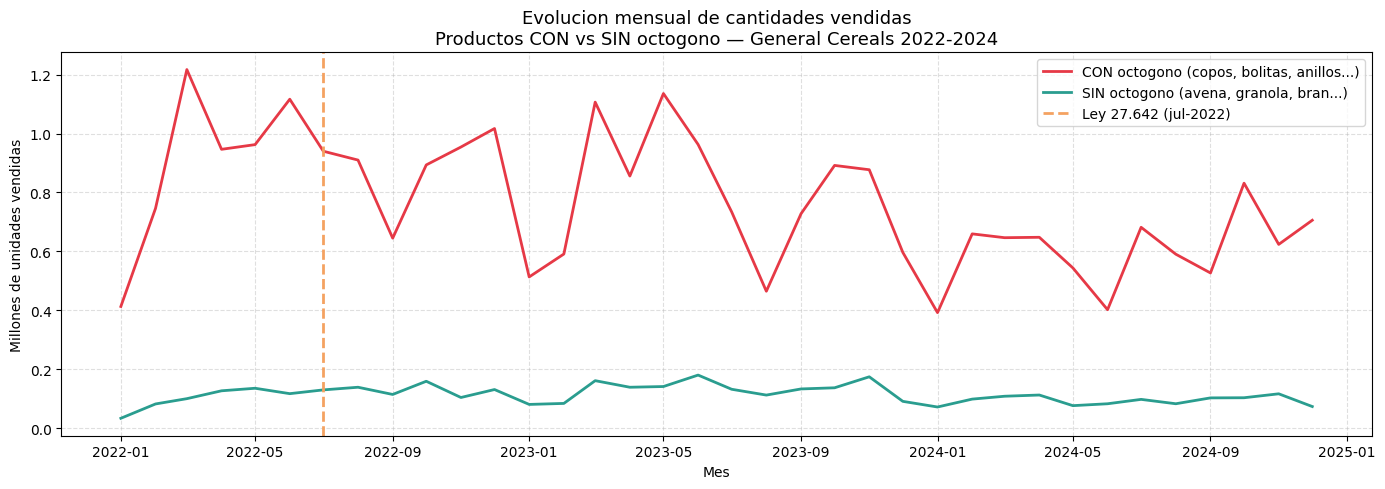

Interpretacion:
Las dos lineas cuentan historias distintas.
Los productos CON octogono vienen de un volumen mucho mas alto en 2022,
pero muestran una tendencia clara hacia abajo que se sostiene en el tiempo.
Los productos SIN octogono arrancan mas bajos, crecen durante 2023 y
caen junto con el consumo general en 2024.
Ambos grupos vivieron la misma inflacion, pero reaccionaron de forma opuesta
en 2023 — cuando la brecha es mas clara — y la distancia acumulada desde 2022
sigue siendo evidente al final del periodo.


In [80]:
df_graf = df_v.copy()

serie = (
    df_graf.groupby(['AÑO_MES','OCTOGONO'])['CANTIDAD']
    .sum().unstack(fill_value=0)
)
serie.index = serie.index.to_timestamp()

plt.figure(figsize=(14,5))
plt.plot(serie.index, serie['CON_OCTOGONO']/1e6,
         color='#e63946', lw=2, label='CON octogono (copos, bolitas, anillos...)')
plt.plot(serie.index, serie['SIN_OCTOGONO']/1e6,
         color='#2a9d8f', lw=2, label='SIN octogono (avena, granola, bran...)')
plt.axvline(pd.Timestamp('2022-07-01'), color='#f4a261',
            lw=2, ls='--', label='Ley 27.642 (jul-2022)')
plt.title('Evolucion mensual de cantidades vendidas\n'
          'Productos CON vs SIN octogono — General Cereals 2022-2024',
          fontsize=13)
plt.xlabel('Mes')
plt.ylabel('Millones de unidades vendidas')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('grafico1_serie_temporal.png', dpi=150)
plt.show()

print('Interpretacion:')
print('Las dos lineas cuentan historias distintas.')
print('Los productos CON octogono vienen de un volumen mucho mas alto en 2022,')
print('pero muestran una tendencia clara hacia abajo que se sostiene en el tiempo.')
print('Los productos SIN octogono arrancan mas bajos, crecen durante 2023 y')
print('caen junto con el consumo general en 2024.')
print('Ambos grupos vivieron la misma inflacion, pero reaccionaron de forma opuesta')
print('en 2023 — cuando la brecha es mas clara — y la distancia acumulada desde 2022')
print('sigue siendo evidente al final del periodo.')

## Grafico 2 — Barras: comparacion pre/post ley por categoria

**Tipo:** Barras agrupadas.

**¿Que muestra?** El promedio mensual de ventas de cada grupo en el periodo pre-ley versus el post-ley, normalizado por meses. Permite ver el impacto neto de un vistazo.


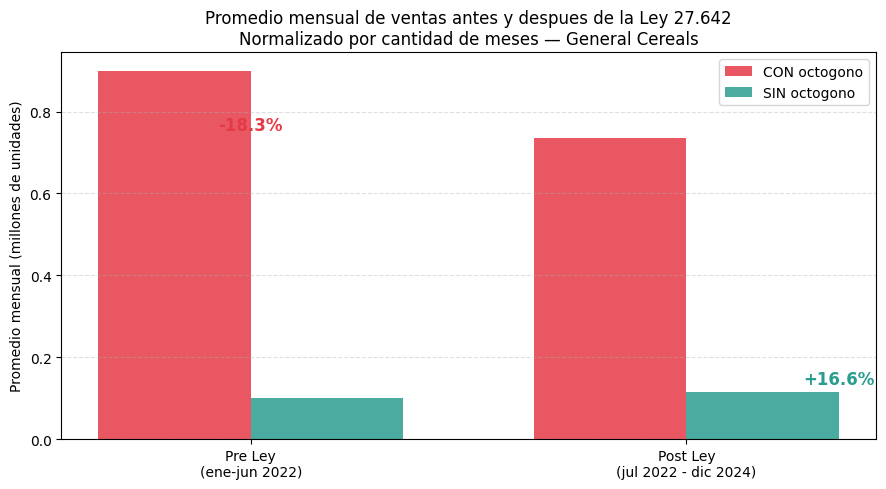

Interpretacion:
Con el mismo punto de partida aproximado y el mismo contexto economico,
un grupo cayo 18,3% y el otro subio 16,6%.
Una brecha de casi 35 puntos porcentuales entre dos grupos dentro de la misma empresa,
bajo la misma inflacion y distribuidos por los mismos canales.
Esa magnitud es consistente con un efecto del etiquetado sobre la demanda, aunque no prueba causalidad por si sola.


In [81]:
df_prom = prom_mensual[['CON_OCTOGONO','SIN_OCTOGONO']]

x = np.arange(2)
w = 0.35

plt.figure(figsize=(9,5))
plt.bar(x,                      df_prom['CON_OCTOGONO']/1e6, w,
        label='CON octogono', color='#e63946', alpha=0.85)
plt.bar(x + w, df_prom['SIN_OCTOGONO']/1e6, w,
        label='SIN octogono', color='#2a9d8f', alpha=0.85)

plt.xticks(x + w/2, ['Pre Ley\n(ene-jun 2022)', 'Post Ley\n(jul 2022 - dic 2024)'])
plt.ylabel('Promedio mensual (millones de unidades)')
plt.title('Promedio mensual de ventas antes y despues de la Ley 27.642\n'
          'Normalizado por cantidad de meses — General Cereals',
          fontsize=12)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.4)

for i, col, color in [(0,'CON_OCTOGONO','#e63946'),(1,'SIN_OCTOGONO','#2a9d8f')]:
    v_pre  = df_prom.loc['PRE_LEY', col]
    v_post = df_prom.loc['POST_LEY', col]
    var = (v_post - v_pre) / v_pre * 100
    plt.annotate(f'{var:+.1f}%',
                 xy=(i + i*w + w/2, v_post/1e6 + 0.01),
                 ha='center', va='bottom', fontweight='bold',
                 color=color, fontsize=12)

plt.tight_layout()
plt.savefig('grafico2_barras.png', dpi=150)
plt.show()

print('Interpretacion:')
print('Con el mismo punto de partida aproximado y el mismo contexto economico,')
print('un grupo cayo 18,3% y el otro subio 16,6%.')
print('Una brecha de casi 35 puntos porcentuales entre dos grupos dentro de la misma empresa,')
print('bajo la misma inflacion y distribuidos por los mismos canales.')
print('Esa magnitud es consistente con un efecto del etiquetado sobre la demanda,'
      ' aunque no prueba causalidad por si sola.')

## Grafico 3 — Diagrama de dispersion: relacion entre el desempeno de CON y SIN

**Tipo:** Diagrama de dispersion (scatter).

**Variables:** indice CON octogono en el eje X vs indice SIN octogono en el eje Y. Ambos indices tienen base 100 = promedio mensual pre-ley de cada grupo. **Cada punto es un mes.** Los puntos estan coloreados por periodo (pre-ley y cada ano post-ley).

**Por que este grafico no repite los anteriores:** el Grafico 1 muestra la evolucion de cada grupo a lo largo del tiempo; el Grafico 2 resume el antes y despues. Este grafico muestra algo distinto: si ambos grupos se moviesen juntos (por ejemplo, por efectos macroeconomicos compartidos), los puntos quedarian sobre la diagonal gris. Cualquier desviacion sistematica de esa diagonal indica que un grupo gano o perdio terreno *relativo* al otro. La diagonal es el contrafactual.

In [ ]:
# Índice mensual por grupo (base 100 = promedio pre-ley de cada grupo)
serie = (
    df_v[df_v['OCTOGONO'].isin(['CON_OCTOGONO', 'SIN_OCTOGONO'])]
    .groupby(['AÑO_MES', 'OCTOGONO'])['CANTIDAD'].sum().unstack(fill_value=0)
)
serie.index = serie.index.to_timestamp()
LEY = pd.Timestamp('2022-07-01')

base_con = serie.loc[serie.index < LEY, 'CON_OCTOGONO'].mean()
base_sin = serie.loc[serie.index < LEY, 'SIN_OCTOGONO'].mean()
idx_con  = serie['CON_OCTOGONO'] / base_con * 100
idx_sin  = serie['SIN_OCTOGONO'] / base_sin * 100

mask_pre = serie.index < LEY

fig, ax = plt.subplots(figsize=(8, 7))

# Pre-ley: marcadores huecos grises
ax.scatter(idx_con[mask_pre], idx_sin[mask_pre],
           s=65, facecolors='none', edgecolors='#6c757d',
           linewidths=1.8, alpha=0.85, zorder=4,
           label='Pre-ley (ene–jun 2022)')

# Post-ley: un color por año
colores = {2022: '#f4a261', 2023: '#e63946', 2024: '#264653'}
for anio in [2022, 2023, 2024]:
    mask = (~mask_pre) & (serie.index.year == anio)
    if mask.any():
        ax.scatter(idx_con[mask], idx_sin[mask],
                   color=colores[anio], s=65, alpha=0.85, zorder=5,
                   label=f'Post-ley {anio}')

# Diagonal de referencia: si ambos grupos se moviesen igual
lim_min = min(idx_con.min(), idx_sin.min()) - 8
lim_max = max(idx_con.max(), idx_sin.max()) + 8
ax.plot([lim_min, lim_max], [lim_min, lim_max],
        color='gray', ls='--', lw=1.2, alpha=0.5,
        label='Sin divergencia (ambos grupos iguales)')

# Líneas de referencia en 100
ax.axhline(100, color='#2a9d8f', ls=':', lw=0.8, alpha=0.35)
ax.axvline(100, color='#e63946', ls=':', lw=0.8, alpha=0.35)

# Anotacion cuadrante
ax.text(55, 145, 'SIN supera\nsu nivel pre-ley\nCON cae',
        fontsize=8, color='#555', ha='center', va='center',
        bbox=dict(facecolor='#fffbe6', edgecolor='#ccc', boxstyle='round,pad=0.3', alpha=0.8))
ax.text(110, 55, 'Ambos\ncaen',
        fontsize=8, color='#555', ha='center', va='center',
        bbox=dict(facecolor='#fffbe6', edgecolor='#ccc', boxstyle='round,pad=0.3', alpha=0.8))

ax.set_xlabel('Indice de volumen — CON octogono\n(100 = promedio mensual ene–jun 2022)', fontsize=10)
ax.set_ylabel('Indice de volumen — SIN octogono\n(100 = promedio mensual ene–jun 2022)', fontsize=10)
ax.set_title('Desempeno relativo: CON vs SIN octogono\n'
             'Cada punto = un mes | Si ambos grupos se moviesen igual, los puntos estarian sobre la diagonal',
             fontsize=10)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.2)
plt.tight_layout()
plt.savefig('grafico3_dispersion.png', dpi=150)
plt.show()

**Interpretacion:**

El grafico muestra la relacion entre el desempeno de los dos grupos mes a mes, usando un indice normalizado para que la escala sea comparable.

- **Pre-ley (circulos grises huecos):** todos los puntos se agrupan cerca del punto (100, 100) y de la diagonal. Antes de la ley, CON y SIN oscilaban juntos alrededor de su propio nivel base. La diagonal es el escenario nulo: si solo la economia explicase la variacion, todos los puntos quedarian sobre ella.

- **Post-ley 2022 (naranja):** los primeros meses post-ley muestran poca divergencia todavia; los puntos se alejan levemente de la diagonal hacia arriba (SIN empieza a superar su base mas rapido que CON).

- **Post-ley 2023 (rojo):** la nube de puntos se desplaza al cuadrante superior izquierdo — CON por debajo de 100 (cayó respecto a la pre-ley), SIN por encima de 100 (subio). La divergencia maxima ocurre este año.

- **Post-ley 2024 (azul oscuro):** ambos grupos caen (contraccion del consumo), pero los puntos siguen por encima de la diagonal: SIN siempre supera a CON *en relacion a su propio nivel pre-ley*.

**Patron de interes:** ningun punto post-ley cae *por debajo* de la diagonal de forma sostenida. Si la inflacion o la caida del consumo fuesen el unico factor, los dos grupos se moveran juntos y los puntos estarian sobre la diagonal. La desviacion sistematica por encima de ella indica que un factor especifico de CON — el etiquetado — explica la brecha.

---
# 3.5 — Aplicacion de conceptos de la materia

Aplicamos un concepto visto en clase: **elasticidad-arco**. Se implementa con funciones documentadas, se aplica al dataset y se interpreta en relacion a la pregunta.

*Asistencia de IA utilizada. Prompt (Ejemplo 1 del enunciado):*
> *'Actua como analista de datos senior. Dataset de ventas cerealeras 2022-2024. La Ley 27.642 opera como un shock de demanda sobre los productos con octogono, simultaneo a la inflacion que afecta a todos los grupos. Implementa elasticidad-arco. Justifica cada decision metodologica y unicamente toma los resumenes adjuntos para la realizacion del enunciado'*


## Concepto 1: Elasticidad-arco precio/cantidad

La **elasticidad precio de la demanda** mide que tan sensible es la cantidad demandada ante un cambio en el precio: si el precio sube 1%, ¿cuanto cambia la cantidad?

Usamos la formula discreta (arco o punto medio), vista en clase:

$$E = \frac{(Q_1 - Q_0) / ((Q_0 + Q_1)/2)}{(P_1 - P_0) / ((P_0 + P_1)/2)}$$

**Interpretacion del resultado:**
- $|E| < 1$: demanda **inelastica** — los consumidores no cambian mucho su compra
- $|E| > 1$: demanda **elastica** — muy sensibles al precio
- Signo negativo: relacion inversa normal (sube precio → baja cantidad)
- Signo positivo inesperado: otros factores compensan el aumento de precio


In [83]:
def elasticidad_arco(q0, q1, p0, p1):
    """
    Calcula la elasticidad-arco (metodo del punto medio) entre dos periodos.

    Parametros:
        q0 (float): cantidad promedio mensual en el periodo base (pre-ley)
        q1 (float): cantidad promedio mensual en el periodo final (post-ley)
        p0 (float): precio promedio en el periodo base
        p1 (float): precio promedio en el periodo final

    Retorna:
        float: elasticidad-arco precio/cantidad
        np.nan: si no hay variacion de precios

    Formula: ((Q1-Q0)/Qmedio) / ((P1-P0)/Pmedio)
    Fuente: Resumen Parcial U3 — Elasticidad precio de la demanda
    """
    delta_q = (q1 - q0) / ((q0 + q1) / 2)
    delta_p = (p1 - p0) / ((p0 + p1) / 2)
    if delta_p == 0:
        return np.nan
    return delta_q / delta_p

print(f'{'Categoria':<18} {'Q_pre/mes':>12} {'Q_post/mes':>12} {'P_pre':>10} {'P_post':>10} {'Var_Q':>8} {'Var_P':>8} {'Elast':>8}')
print('-'*92)

resultados_e = []
for grupo in ['CON_OCTOGONO','SIN_OCTOGONO']:
    sub  = df_v[df_v['OCTOGONO']==grupo]
    pre  = sub[sub['PERIODO']=='PRE_LEY']
    post = sub[sub['PERIODO']=='POST_LEY']
    q0 = pre['CANTIDAD'].sum()  / meses_pre
    q1 = post['CANTIDAD'].sum() / meses_post
    p0 = pre['PRECIO'].mean()
    p1 = post['PRECIO'].mean()
    e  = elasticidad_arco(q0, q1, p0, p1)
    vq = (q1-q0)/q0*100
    vp = (p1-p0)/p0*100
    resultados_e.append({'grupo':grupo,'q0':q0,'q1':q1,'p0':p0,'p1':p1,'vq':vq,'vp':vp,'e':e})
    print(f'{grupo:<18} {q0:>12,.0f} {q1:>12,.0f} {p0:>10,.0f} {p1:>10,.0f} {vq:>7.1f}% {vp:>7.1f}% {e:>8.4f}')


Categoria             Q_pre/mes   Q_post/mes      P_pre     P_post    Var_Q    Var_P    Elast
--------------------------------------------------------------------------------------------
CON_OCTOGONO            900,197      735,604      1,982     10,072   -18.3%   408.3%  -0.1499
SIN_OCTOGONO             99,308      115,796      2,279     12,570    16.6%   451.6%   0.1106


In [ ]:
e_con = resultados_e[0]
e_sin = resultados_e[1]

# Precios reales de T3 (pre y post ley, por grupo)
p_real = {}
for grupo in ['CON_OCTOGONO', 'SIN_OCTOGONO']:
    sub = df_v[df_v['OCTOGONO'] == grupo]
    p_real[grupo] = {
        'pre':  sub[sub['PERIODO'] == 'PRE_LEY']['PRECIO_REAL'].mean(),
        'post': sub[sub['PERIODO'] == 'POST_LEY']['PRECIO_REAL'].mean(),
    }
    p_real[grupo]['var'] = (p_real[grupo]['post'] - p_real[grupo]['pre']) / p_real[grupo]['pre'] * 100

print('=== INTERPRETACION ===')
print()
print(f'CON octogono: E = {e_con["e"]:.4f} -> demanda INELASTICA con caida de volumen')
print(f'  Precio nominal: ${e_con["p0"]:,.0f} -> ${e_con["p1"]:,.0f} ({e_con["vp"]:+.1f}%)')
print(f'  Precio real   : ${p_real["CON_OCTOGONO"]["pre"]:,.0f} -> ${p_real["CON_OCTOGONO"]["post"]:,.0f} ({p_real["CON_OCTOGONO"]["var"]:+.1f}%) [T3]')
print(f'  Cantidad      : {e_con["vq"]:+.1f}%')
print(f'  Por cada 1% de aumento de precio nominal, la cantidad cayo un {abs(e_con["e"]):.2f}%.')
print(f'  La demanda es inelastica: la caida de cantidad fue menor que el aumento de precio.')
print()
print(f'SIN octogono: E = {e_sin["e"]:.4f} -> elasticidad POSITIVA (inusual)')
print(f'  Precio nominal: ${e_sin["p0"]:,.0f} -> ${e_sin["p1"]:,.0f} ({e_sin["vp"]:+.1f}%)')
print(f'  Precio real   : ${p_real["SIN_OCTOGONO"]["pre"]:,.0f} -> ${p_real["SIN_OCTOGONO"]["post"]:,.0f} ({p_real["SIN_OCTOGONO"]["var"]:+.1f}%) [T3]')
print(f'  Cantidad      : {e_sin["vq"]:+.1f}%')
print(f'  El precio real de SIN subio mas que el de CON ({p_real["SIN_OCTOGONO"]["var"]:+.1f}% vs {p_real["CON_OCTOGONO"]["var"]:+.1f}%),')
print(f'  pero la cantidad igualmente crecio. Esto confirma que la diferencia no es')
print(f'  de precio: es de preferencia. Los consumidores migraron hacia SIN a pesar')
print(f'  de que ese grupo se encarecio mas en terminos reales.')
print()
print('NOTA METODOLOGICA: la elasticidad-arco usa precios NOMINALES (formula del punto')
print('medio, vista en clase). El analisis de precio real (T3) es complementario y')
print('sirve para verificar que la divergencia de cantidades no se explica por precio.')